**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

:*   NOMBRE: Eduardo Miguel Paz Calvopiña
*   MATRÍCULA: A00886517

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [41]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MIAA/7.1 Aprende | Aprendizaje no supervisado/Actividad 7"
os.chdir(DIR)

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [8]:
cars_df = pd.read_csv('automobile_dataset.csv')
cars_df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [9]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

**Tipos de Datos:** 11 son numéricos y 15 de texto

In [10]:
# símbolo '?' por cada columna
columnas_con_signo = (cars_df == '?').sum()
print(columnas_con_signo[columnas_con_signo > 0])

normalized_losses    41
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64


In [11]:
# Sustituir el símbolo '?' por valores faltantes (NaN)
cars_df.replace('?', np.nan, inplace=True)

In [12]:
# Convertir las columnas al tipo de dato adecuado - por el símbolo '?', muchas columnas numéricas se cargaron como 'object'.
cols_a_convertir = ['normalized_losses', 'bore', 'stroke',
    'horsepower', 'peak_rpm', 'price']

for col in cols_a_convertir:
    cars_df[col] = pd.to_numeric(cars_df[col], errors='coerce')


In [13]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

**Tipos de Datos:** 17 son numéricos y 9 de texto

Después de correguir tipo de datos

In [14]:
cars_df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

## **Calidad de Datos (Duplicados y Faltantes)**

In [15]:
# Verificar si hay registros duplicados
total_duplicados = cars_df.duplicated().sum()
print(f"Total de registros duplicados: {total_duplicados}")

# Porcentaje de valores faltantes por columna
porcentaje_faltantes = (cars_df.isna().mean() * 100)
print("\nPorcentaje de valores faltantes por columna:")
print(porcentaje_faltantes[porcentaje_faltantes > 0])

Total de registros duplicados: 0

Porcentaje de valores faltantes por columna:
normalized_losses    20.00000
bore                  1.95122
stroke                1.95122
horsepower            0.97561
peak_rpm              0.97561
price                 1.95122
dtype: float64


## **Estadísticas Descriptivas**

In [16]:
# Identificar columnas por tipo
num_cols = cars_df.select_dtypes(include=['number']).columns
cat_cols = cars_df.select_dtypes(include=['object', 'category']).columns

In [17]:
# Estadísticas para numéricas (incluyendo skew y kurtosis)
print("Estadísticas descriptivas numéricas:")
stats_num = cars_df[num_cols].describe().T
stats_num['skewness'] = cars_df[num_cols].skew()
stats_num['kurtosis'] = cars_df[num_cols].kurt()
print(stats_num)

Estadísticas descriptivas numéricas:
                   count          mean          std      min      25%  \
symboling          205.0      0.834146     1.245307    -2.00     0.00   
normalized_losses  164.0    122.000000    35.442168    65.00    94.00   
wheel_base         205.0     98.756585     6.021776    86.60    94.50   
length             205.0    174.049268    12.337289   141.10   166.30   
width              205.0     65.907805     2.145204    60.30    64.10   
height             205.0     53.724878     2.443522    47.80    52.00   
curb_weight        205.0   2555.565854   520.680204  1488.00  2145.00   
num_cylinders      205.0      4.380488     1.080854     2.00     4.00   
engine_size        205.0    126.907317    41.642693    61.00    97.00   
bore               201.0      3.329751     0.273539     2.54     3.15   
stroke             201.0      3.255423     0.316717     2.07     3.11   
compression_ratio  205.0     10.142537     3.972040     7.00     8.60   
horsepower    

In [18]:
# Tablas de frecuencia por categóricas
print("\nFrecuencias de variables categóricas:")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(cars_df[col].value_counts())


Frecuencias de variables categóricas:

--- make ---
make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64

--- fuel_type ---
fuel_type
gas       185
diesel     20
Name: count, dtype: int64

--- aspiration ---
aspiration
std      168
turbo     37
Name: count, dtype: int64

--- num_doors ---
num_doors
four    116
two      89
Name: count, dtype: int64

--- body_style ---
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

--- drive_wheels ---
drive_wheels
fwd    120
rwd     76
4wd      9
Name: count, dty

## **Visualización**

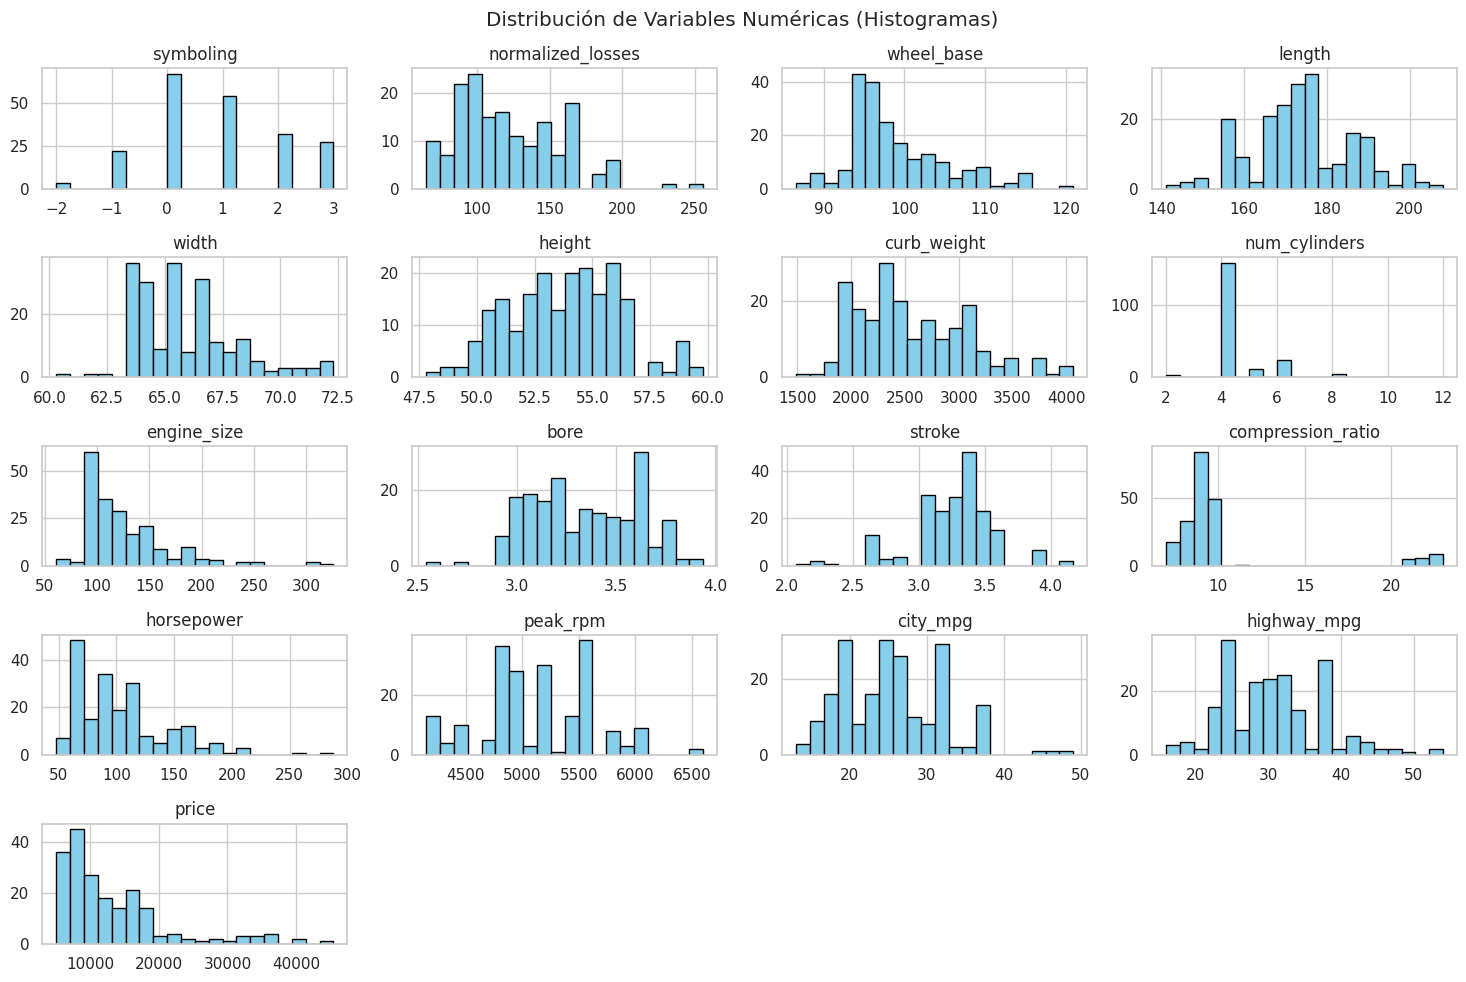

In [19]:
sns.set(style="whitegrid")

# Histogramas para variables numéricas
cars_df[num_cols].hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas (Histogramas)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


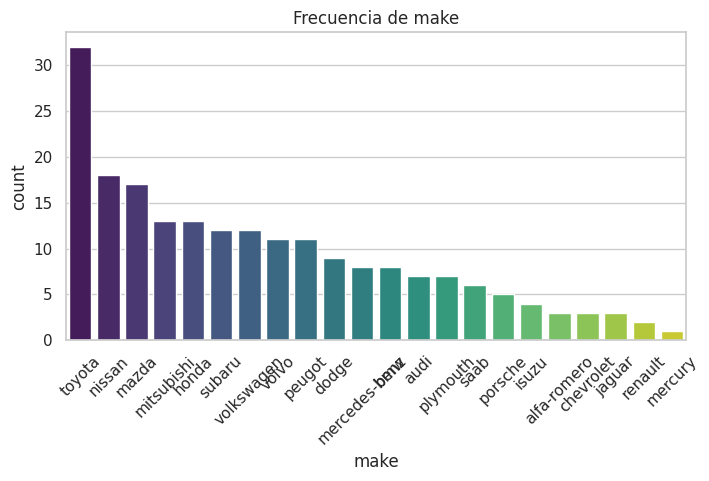

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


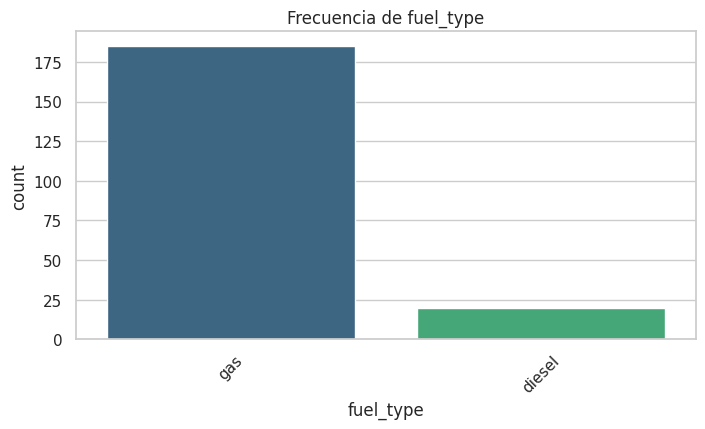

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


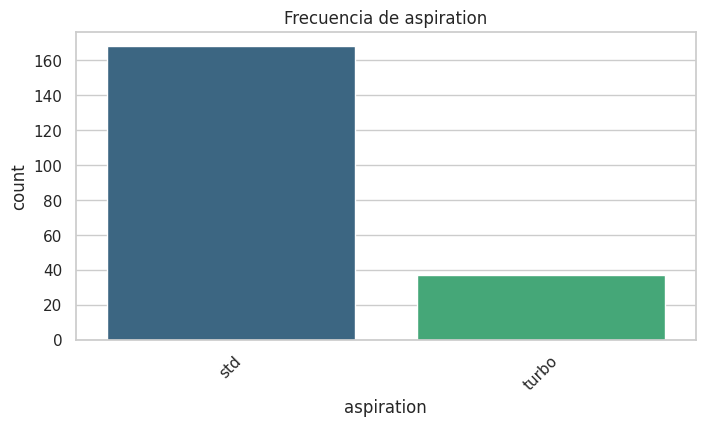

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


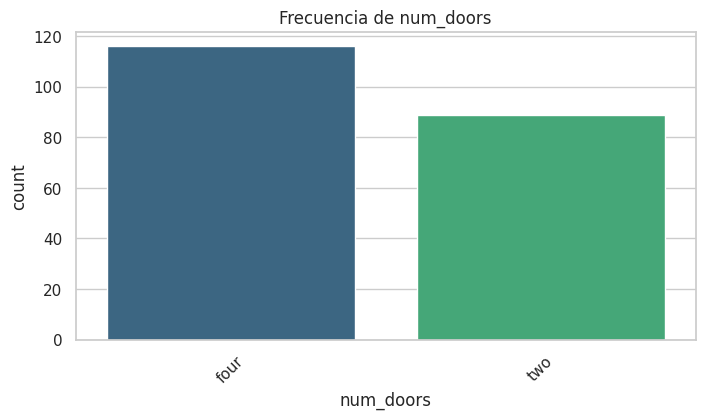

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


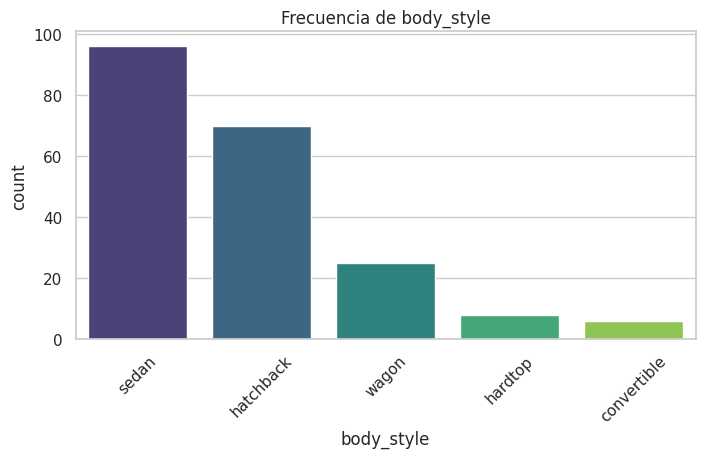

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


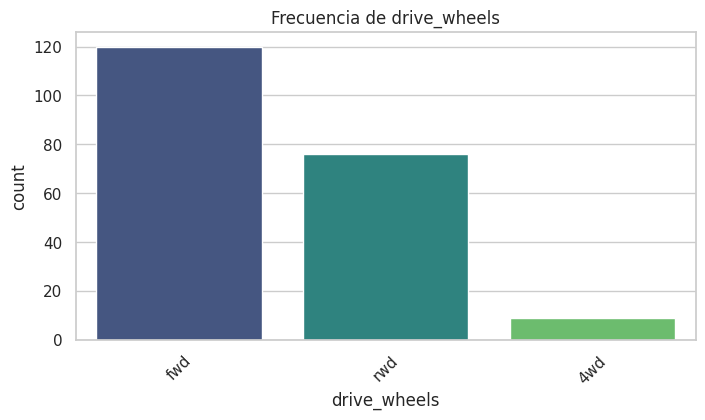

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


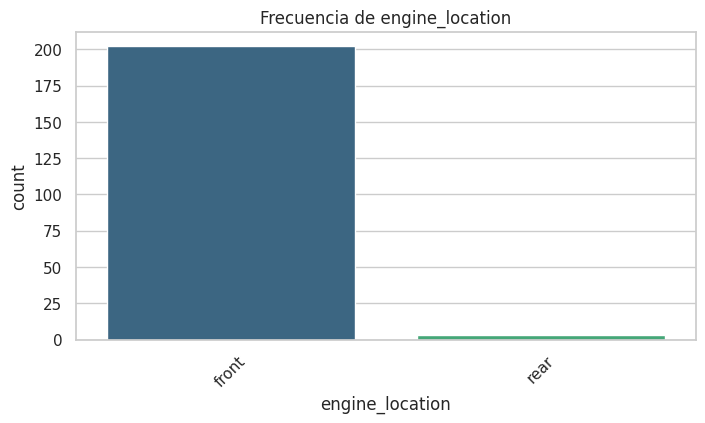

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


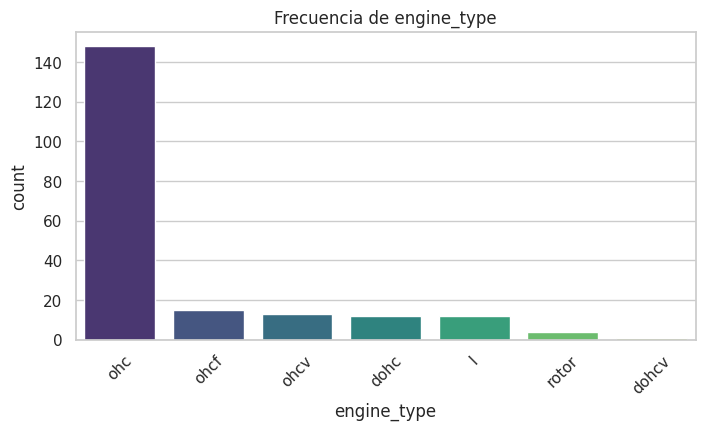

/tmp/ipython-input-27196/230338701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')


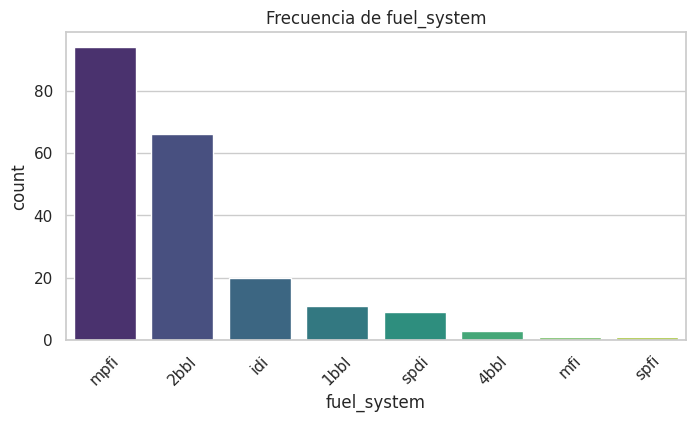

In [20]:
# Diagramas de barras para variables categóricas
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=cars_df, x=col, order=cars_df[col].value_counts().index, palette='viridis')
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=45)
    plt.show()

# **Análisis exploratorio de datos (bivariado)**

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

# **Gráfico de barras apiladas normalizadas**

Distribución de los tipos de tracción (drive_wheels) para cada fabricante (make)

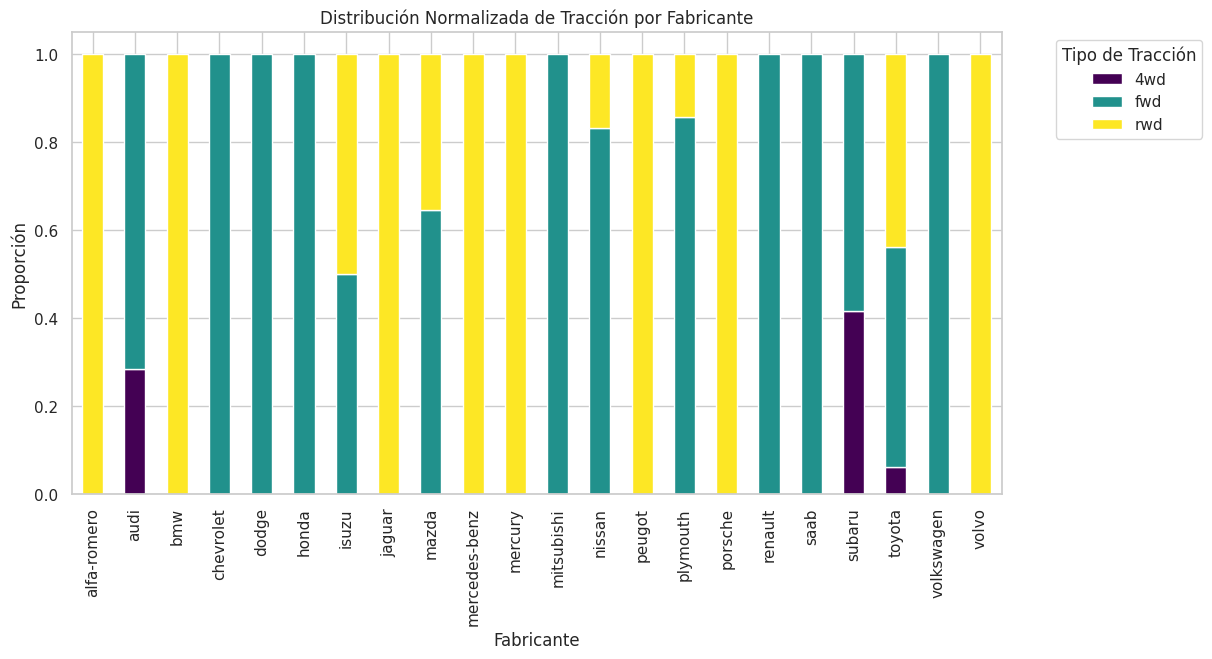

In [21]:
# Crear tabla de contingencia y normalizar por filas (fabricante)
traccion_pct = pd.crosstab(cars_df['make'], cars_df['drive_wheels'], normalize='index')

# Graficar
traccion_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Distribución Normalizada de Tracción por Fabricante')
plt.xlabel('Fabricante')
plt.ylabel('Proporción')
plt.legend(title='Tipo de Tracción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
#Capítulo 9: Plotting and Visualization

**Conclusión:**

**Tracción trasera (rwd):** Alfa-Romero, BMW, Jaguar, Mercedes-Benz, Mercury, Peugot, Porche y Volvo prefieren tracción trasera (rwd) y en efecto la usan por completo especializándose en la misma. Otros Fabricantes como Isuzu, Mazda y Toyota la usan en menor pocentaje que la Tracción delantera (fwd) pero muy cerca del 50/50. Por otro lado vnissan y plymouth lo usan en menor porcentaje

**Tracción delantera (fwd):**  Chevrolet, Dodge, honda, Mitsubishi, Renault, Saab, Volkswagen refieren tracción delantera (fwd) y en efecto la usan por completo especializándose en la misma.

**4 wheel Drive(4wd):** Solo Audi, Subaru y Toyota usan 4WD

Estas conclusiones son basadas en los datos que se analizan.

## **Diagrama de cajas (Boxplot)**

/tmp/ipython-input-27196/3623985665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cars_df, x='body_style', y='price', palette='Set2')


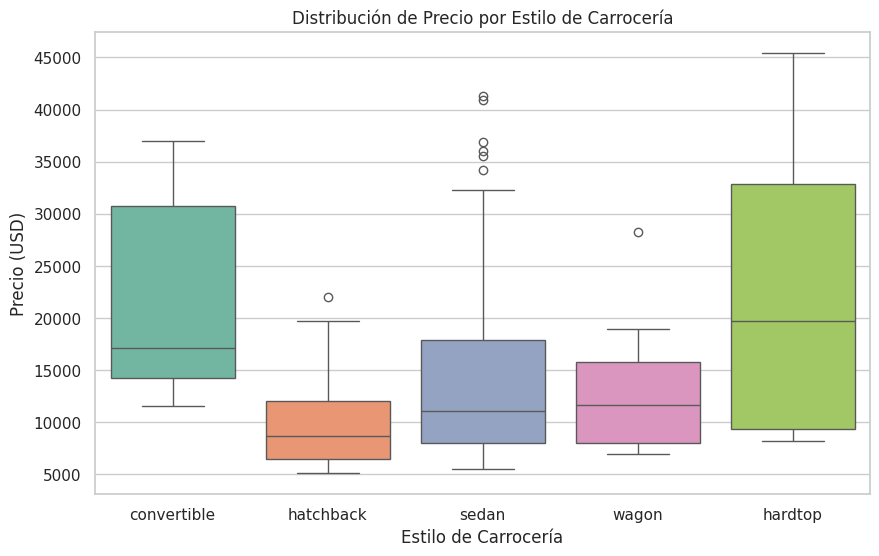

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=cars_df, x='body_style', y='price', palette='Set2')
plt.title('Distribución de Precio por Estilo de Carrocería')
plt.xlabel('Estilo de Carrocería')
plt.ylabel('Precio (USD)')
plt.show()

**Conclusión:**

**Estilo de carrocería más costoso:** Hartop y convertibles con los estilos de carrocería que tienen un precio más elevado. Sin embargo **Hardtop tiene la mediana más alta** de todos los estilos. El 50% central de los hardtops se mueve entre aprox 9K y 33K

**Estilo de carrocería con mayor variabilidad de precios:** El IQR más amplio lo presenta también Hardtop, esto muestra la mayor dispersión tanto en su 50% central como en sus extremos sin embargo no presenta outliers

**Estilo de carrocería con mayor cantidad de outliers:** La carrocería con mayor presencia de outliers (tanto en cantidad como en magnitud de precios atípicamente altos) es sedan.

## **Gráfico de barras: Top 10 automóviles más caros**

/tmp/ipython-input-27196/2215063706.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


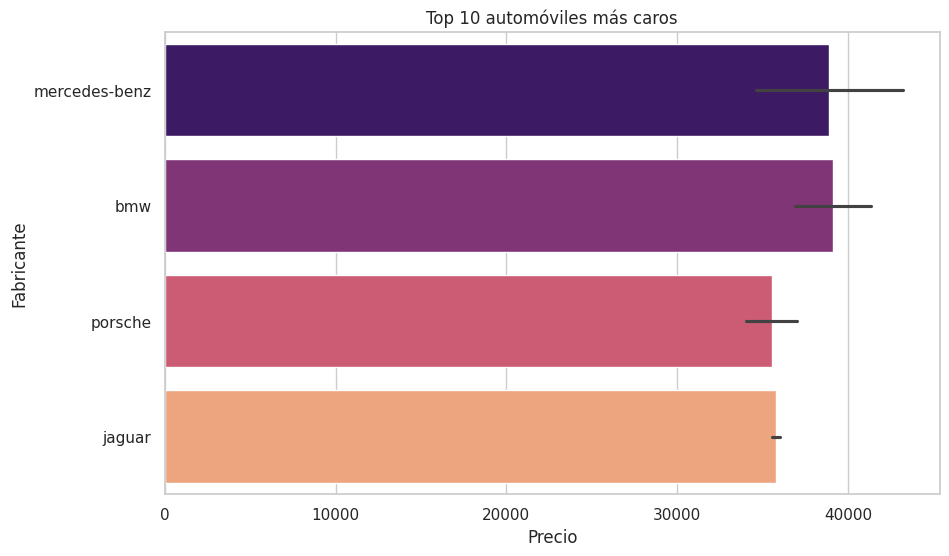

In [23]:
# Obtener los 10 más caros
top_10_caros = cars_df.nlargest(10, 'price')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_caros, x='price', y='make', hue='make', palette='magma', dodge=False)
plt.title('Top 10 automóviles más caros')
plt.xlabel('Precio')
plt.ylabel('Fabricante')
plt.legend().remove()
plt.show()

**Conclusión:**

Mercedes-Benz y BMW compiten por el primer lugar con la oferta de coches más caros, junto con porche y jaguar. Esto tiene sentido ya que su nicho de mercado son autos de lujo.

## **Diagrama de dispersión (Scatter plot)**

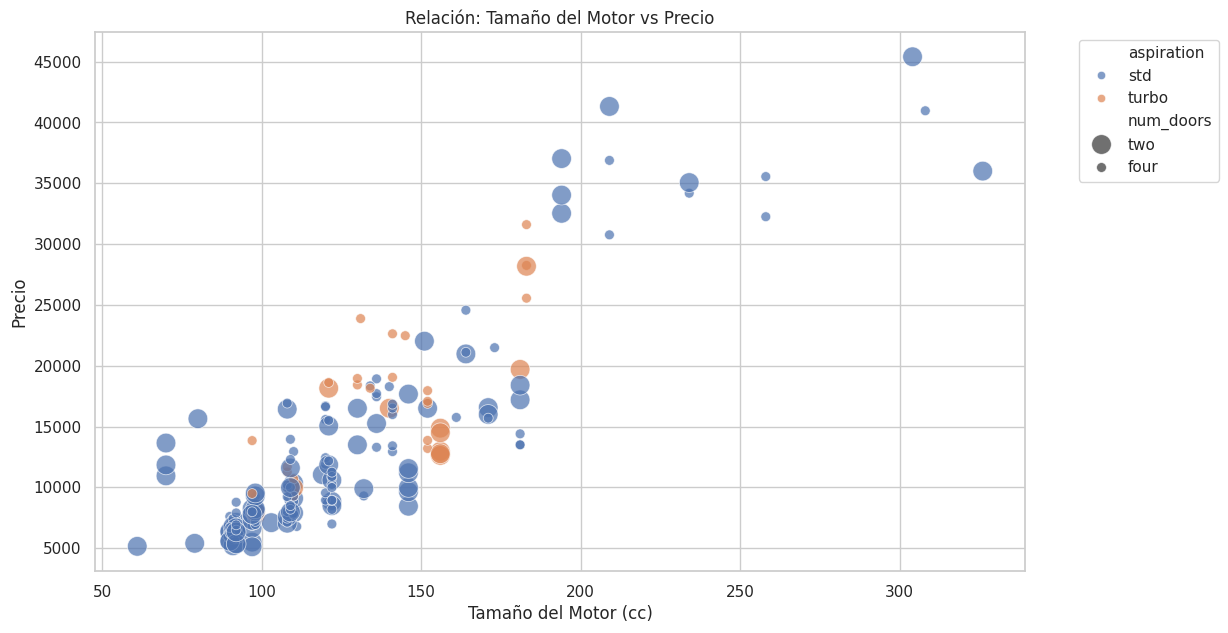

In [24]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=cars_df, x='engine_size', y='price',
                hue='aspiration', size='num_doors',
                sizes=(50, 200), alpha=0.7)
plt.title('Relación: Tamaño del Motor vs Precio')
plt.xlabel('Tamaño del Motor (cc)')
plt.ylabel('Precio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Conclusión:**

Existe una correlación positiva moderada-fuerte. El scatter plot muestra una tendencia ascendente, a mayor cilindrada, el precio promedio y el techo de precios aumenta de forma consistente.

El turbo tiene un efecto alcista en el precio (premium de tecnología). Se observa que cuando analizamos el mismo motor, los puntos naranjas están por encima de los azules (std).

Hay correlación positiva entre tamaño de motor y precio, pero el turbo actúa como un fuerte multiplicador de precio con el mismo tamaño de motor

4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

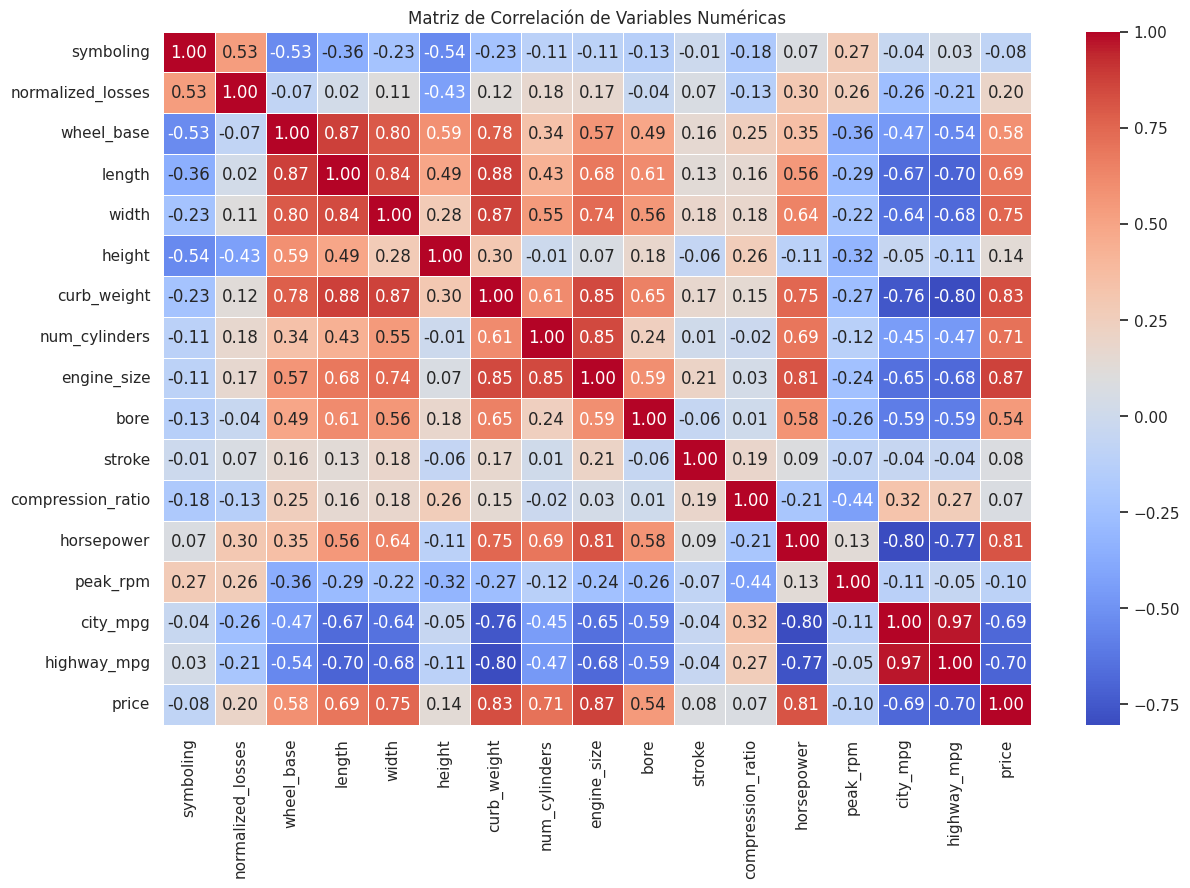

In [25]:
#mapa de calor (heatmap)
matriz_corr = cars_df.corr(numeric_only=True)
plt.figure(figsize=(14, 9))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**engine_size (+0.87), curb_weight (+0.83), horsepower (+0.81)** son las variables más correlacionadas con el precio

In [26]:
# variables más correlacionadas con el precio
correlacion_precio = matriz_corr['price'].abs().sort_values(ascending=False)

print("Variables con mayor correlación absoluta con el precio:")
print(correlacion_precio[1:4])

Variables con mayor correlación absoluta con el precio:
engine_size    0.872335
curb_weight    0.834415
horsepower     0.810533
Name: price, dtype: float64


En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [27]:
#Imputación de Valores Faltantes
# Predictores numéricos (x)
X_num = cars_df.select_dtypes(include=['number']).drop(columns=['price'])

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_num)

X_imputed_df = pd.DataFrame(X_imputed, columns=X_num.columns)

**Justificación:** Se optó por la estrategia de imputación con la mediana debido a que varias variables clave del dataset (como horsepower, engine_size, compression_ratio y num_cylinders) presentan distribuciones fuertemente sesgadas (asimetría > 0.75) y contienen valores atípicos evidentes (curtosis elevada, especialmente en num_cylinders y engine_size). En estos casos, la mediana resulta mucho más robusta que la media, ya que no se ve distorsionada por los outliers ni por la asimetría.

In [28]:
#Definición de Variables (X, y)
# Variable objetivo
y = cars_df['price']
#Variable predictores
X = X_imputed_df

In [29]:
# número de variables en X
print(f" {X.shape[1]} componentes principales.")

 16 componentes principales.


In [30]:
#Escalamiento de Datos

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Datos escalados:")
X_scaled_df.head()

Datos escalados:


,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,1.743470,-0.176503,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,0.520489,-1.841345,-0.288349,0.173309,-0.264983,-0.646553,-0.546059
1,1.743470,-0.176503,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,0.520489,-1.841345,-0.288349,0.173309,-0.264983,-0.646553,-0.546059
2,0.133509,-0.176503,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,1.502032,0.604046,-2.403313,0.683683,-0.288349,1.263761,-0.264983,-0.953012,-0.691627
3,0.938490,1.367901,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.352887,-0.431076,-0.515795,0.459947,-0.035973,-0.054925,0.785723,-0.186865,-0.109354
4,0.938490,1.367901,0.107110,0.207256,0.230001,0.235942,0.516807,0.574572,0.218885,-0.515795,0.459947,-0.540725,0.274747,0.785723,-1.106241,-1.273900


6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

In [31]:
pca = PCA()
pca_data = pca.fit_transform(X_scaled)

# Se asignan nombres PC1, PC2...
n_pcs = X_scaled.shape[1]
nombres_pcs = [f'PC{i+1}' for i in range(n_pcs)]
pca_df = pd.DataFrame(pca_data, columns=nombres_pcs)

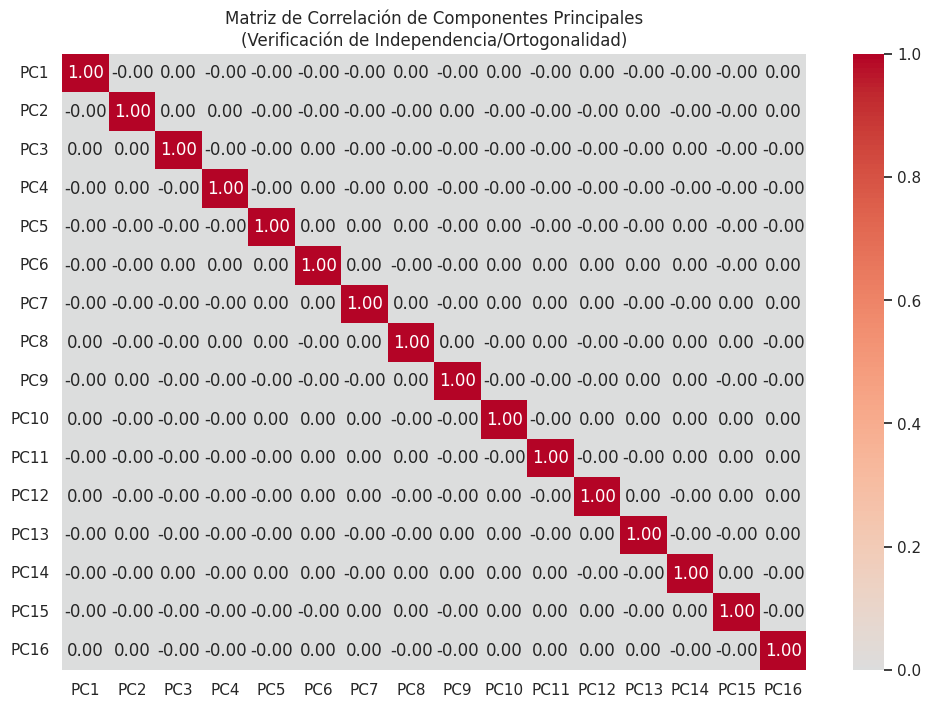

In [32]:
# 4. Verificación de Independencia (Mapa de Calor)
# Las notas indican que los componentes deben ser independientes (perpendiculares entre sí) [6].
plt.figure(figsize=(12, 8))
sns.heatmap(pca_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Componentes Principales\n(Verificación de Independencia/Ortogonalidad)')
plt.show()

In [33]:
# Visualización de los nuevos ejes (proyecciones)
print("Primeros registros de los datos proyectados en el nuevo espacio de vectores:")
pca_df.head()

Primeros registros de los datos proyectados en el nuevo espacio de vectores:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.288788,-1.088415,-0.347735,-0.474581,0.267610,-0.273617,0.362346,0.185204,0.003853
1,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.288788,-1.088415,-0.347735,-0.474581,0.267610,-0.273617,0.362346,0.185204,0.003853
2,0.634430,-1.372747,0.872496,0.998222,1.834717,-0.774751,-0.515065,1.370499,-1.130802,-1.013703,0.502983,0.657052,0.174955,-0.008520,0.118635,-0.111688
3,-0.361470,-0.919214,0.451578,-1.489124,-0.269938,-0.789900,0.000484,0.400032,0.293338,0.168137,0.039239,-0.022832,-0.078891,-0.391786,0.009265,0.053641
4,1.172393,-1.794960,0.183773,-1.083812,0.113486,-0.861858,-0.353900,0.870186,0.015429,-0.447054,-0.055376,-0.416053,-0.049431,0.079357,-0.198402,0.046303


7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

In [34]:
# Obtener la varianza individual
varianza_individual = pca.explained_variance_ratio_ * 100

for i, var in enumerate(varianza_individual):
    print(f"PC{i+1} explica el {var:.2f}% de la varianza.")

PC1 explica el 44.55% de la varianza.
PC2 explica el 17.93% de la varianza.
PC3 explica el 8.58% de la varianza.
PC4 explica el 6.44% de la varianza.
PC5 explica el 5.74% de la varianza.
PC6 explica el 4.78% de la varianza.
PC7 explica el 3.25% de la varianza.
PC8 explica el 2.73% de la varianza.
PC9 explica el 1.94% de la varianza.
PC10 explica el 1.55% de la varianza.
PC11 explica el 0.75% de la varianza.
PC12 explica el 0.63% de la varianza.
PC13 explica el 0.51% de la varianza.
PC14 explica el 0.35% de la varianza.
PC15 explica el 0.16% de la varianza.
PC16 explica el 0.12% de la varianza.


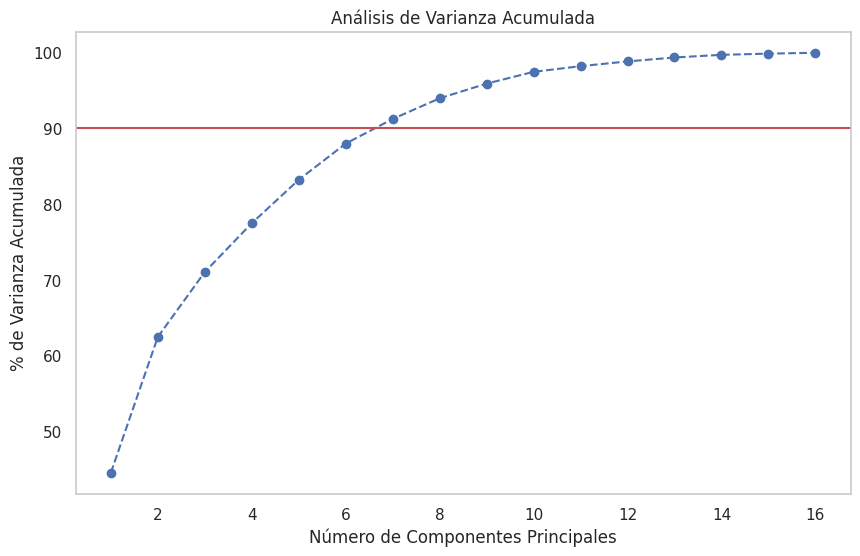

In [35]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_) * 100

# Curva de varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=90, color='r', linestyle='-')
plt.title('Análisis de Varianza Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('% de Varianza Acumulada')
plt.grid()
plt.show()

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

In [36]:
# Cargas de los componentes
n_componentes_seleccionados = 7  # contribuyen 91.27%
pc_Carga = pd.DataFrame(
    abs(pca.components_[:n_componentes_seleccionados]),
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(n_componentes_seleccionados)])

print("Cargas de las variables originales en los componentes principales:")
display(pc_Carga)

Cargas de las variables originales en los componentes principales:


,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
PC1,0.097417,0.015730,0.297827,0.337567,0.334154,0.113918,0.361949,0.245179,0.330140,0.262714,0.052419,0.015923,0.298459,0.086676,0.305762,0.317429
PC2,0.402752,0.330804,0.264598,0.138656,0.055178,0.421734,0.022448,0.114115,0.081608,0.003082,0.034366,0.360906,0.276244,0.363743,0.244770,0.195079
PC3,0.265425,0.308304,0.029492,0.043866,0.108578,0.282463,0.080318,0.176730,0.198927,0.138240,0.511606,0.490226,0.009763,0.256993,0.197583,0.191105
PC4,0.071656,0.343111,0.228250,0.194123,0.097712,0.186128,0.025091,0.552089,0.295503,0.040725,0.430712,0.000951,0.165332,0.289243,0.166746,0.156333
PC5,0.365914,0.376068,0.004383,0.073522,0.016414,0.016741,0.042322,0.236661,0.108753,0.373004,0.571744,0.233770,0.109046,0.341047,0.012215,0.007339
PC6,0.173471,0.492124,0.183468,0.082219,0.107151,0.214021,0.013540,0.354144,0.015613,0.511877,0.364450,0.090066,0.065773,0.281574,0.107088,0.078351
PC7,0.127779,0.322614,0.106348,0.008702,0.139884,0.002597,0.061154,0.068332,0.073093,0.126249,0.152706,0.614078,0.223857,0.604268,0.032927,0.046854


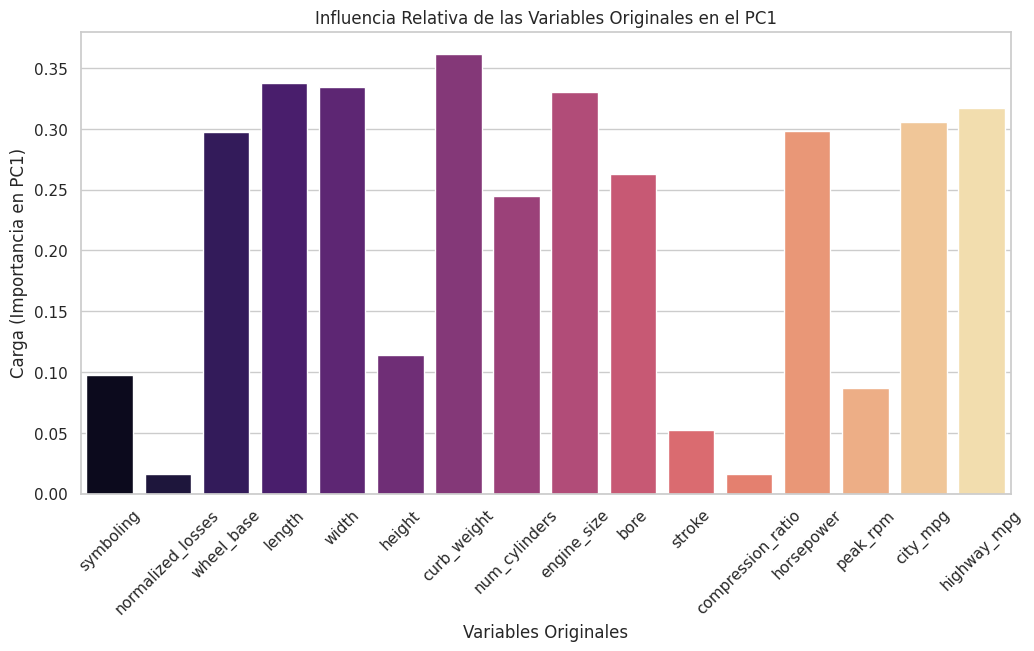

In [37]:
# gráfico de barras para PC1
plt.figure(figsize=(12, 6))
sns.barplot(data=pc_Carga.iloc[0:1], palette='magma')

# Añadir etiquetas y título
plt.title('Influencia Relativa de las Variables Originales en el PC1')
plt.xlabel('Variables Originales')
plt.ylabel('Carga (Importancia en PC1)')
plt.xticks(rotation=45)
plt.show()

Las variables que aportan más al PC1 son: curb_weight, length, width y engine size.

Estas están relacionadas con las dimensiones físicas y la potencia. PC1 representa la Magnitud y Robustez del automóvil.

9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [38]:
# One Hot Encoding (Dummy)
cat_cols = cars_df.select_dtypes(include=['object', 'category']).columns
cars_encoded_df = pd.get_dummies(cars_df[cat_cols], drop_first=True)
cars_encoded_df = cars_encoded_df.astype(int)
print(f"Dimensiones de las variables categóricas tras la codificación: {cars_encoded_df.shape}")
cars_encoded_df.head()

Dimensiones de las variables categóricas tras la codificación: (205, 44)


,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [39]:
#Componentes Principales
n_comp = 7 #
final_pcs = pca_df.iloc[:, :n_comp]

#Concatenación del DataFrame = PCs seleccionados + Variables codificadas + Variable objetivo (price)
df_final = pd.concat([final_pcs, cars_encoded_df, y.reset_index(drop=True)], axis=1)

print(f"Conjunto de datos final: {df_final.shape}")
df_final.head()

Conjunto de datos final: (205, 52)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,make_chevrolet,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0,0,0,...,0,0,0,0,0,0,1,0,0,13495.0
1,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0,0,0,...,0,0,0,0,0,0,1,0,0,16500.0
2,0.634430,-1.372747,0.872496,0.998222,1.834717,-0.774751,-0.515065,0,0,0,...,1,0,0,0,0,0,1,0,0,16500.0
3,-0.361470,-0.919214,0.451578,-1.489124,-0.269938,-0.789900,0.000484,1,0,0,...,0,0,0,0,0,0,1,0,0,13950.0
4,1.172393,-1.794960,0.183773,-1.083812,0.113486,-0.861858,-0.353900,1,0,0,...,0,0,0,0,0,0,1,0,0,17450.0


In [40]:
# Guardar el dataframe resultante en un archivo
df_final.to_csv('cars_final_dataset.csv', index=False)
print("El archivo 'cars_final_dataset.csv' ha sido generado exitosamente.")

El archivo 'cars_final_dataset.csv' ha sido generado exitosamente.
